# 05 — Capacity Allocation Model (Greater London)

**Method note (carried into the proposal):** the joint MILP formulation (binary or
continuous assignment + integer capacity, solved simultaneously across ~4,994 LSOAs) was
tested extensively and proved persistently infeasible or impractically slow, across many
rounds of parameter correction (Uj, K margin, k-NN neighbourhood size, hub-escape
candidates, continuous-flow relaxation). Root cause: jointly optimising "who is assigned
to whom" and "how much capacity goes where" over a very unevenly distributed existing-
supply base (eⱼ ranges from 0 to several hundred at a few hub locations) creates a
fragile combinatorial structure highly sensitive to pruning choices.

This notebook uses a **two-part method that keeps every substantive modelling decision
from the proposal** — Dᵢ(α), eⱼ, K, integer xⱼ, the p budget — **but decouples capacity
allocation from distance evaluation**, each solved by simple, always-correct
arithmetic/nearest-neighbour operations rather than a joint solver:

1. **Capacity allocation**: consistent with the declared dᵢᵢ=0 zonal-aggregation
   simplification (Limitation L7), each LSOA's own demand Dᵢ is compared against its own
   existing supply eᵢ. shortfall_i = max(0, Dᵢ/K − eᵢ). The p new capacity units are
   distributed across all LSOAs in proportion to shortfall.
2. **Evaluation**: every LSOA is assigned to its nearest LSOA with positive total
   capacity (existing + newly allocated), for distance-based metrics (M1/M2-style).

## 0. Setup and reload cleaned data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

demand_london = pd.read_csv(os.path.join(BASE, "05_processed/demand_london.csv"))
seff_london   = pd.read_csv(os.path.join(BASE, "05_processed/seff_london.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))

outputs_dir = os.path.join(BASE, "06_outputs")
os.makedirs(outputs_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"demand_london: {demand_london.shape}, seff_london: {seff_london.shape}")

Datasets reloaded.
demand_london: (4994, 16), seff_london: (4994, 7)


## 1. LSOA centroids (I = J)

In [2]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

london_codes = set(demand_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]

lsoa_london["centroid"] = lsoa_london.geometry.centroid
lsoa_london["cx"] = lsoa_london["centroid"].x
lsoa_london["cy"] = lsoa_london["centroid"].y

lsoa_master = lsoa_london[["lsoa_code", "cx", "cy"]].merge(
    demand_london[["lsoa_code", "D_A", "D_B", "D_C", "D_D"]], on="lsoa_code", how="inner"
).merge(seff_london[["lsoa_code", "ej"]], on="lsoa_code", how="left").reset_index(drop=True)
lsoa_master["ej"] = lsoa_master["ej"].fillna(0)

# Vi = Hi x Ci (household vehicle stock) -- fixed weights for M1/M2, per proposal 5.5
lsoa_master = lsoa_master.merge(census_london[["lsoa_code", "Hi", "Ci"]], on="lsoa_code", how="left")
lsoa_master["Vi"] = lsoa_master["Hi"] * lsoa_master["Ci"]

# income_decile -- evaluation-only grouping for M3, not used in Di anywhere
lsoa_master = lsoa_master.merge(imd_london[["lsoa_code", "income_decile"]], on="lsoa_code", how="left")

n = len(lsoa_master)
coords = lsoa_master[["cx", "cy"]].to_numpy()
print(f"LSOA master table: {n} LSOAs (should be ~4,994)")
lsoa_master.head()

LSOA master table: 4994 LSOAs (should be ~4,994)


,lsoa_code,cx,cy,D_A,D_B,D_C,D_D,ej,Hi,Ci,Vi,income_decile
0,E01000001,532151.194178,181615.201393,41.589935,40.636176,38.860757,37.242036,1,837.0,0.395460,331.0,10
1,E01000002,532443.686041,181645.724884,38.930980,38.057193,36.430638,34.947644,8,824.0,0.359223,296.0,10
2,E01000003,532207.014825,182030.129598,27.642857,27.262493,26.554447,25.908893,0,1017.0,0.216323,220.0,8
3,E01000005,533618.348516,181157.354255,14.952273,14.898271,14.797746,14.706094,0,479.0,0.248434,119.0,5
4,E01000006,544934.369716,184297.546524,64.835065,65.436017,66.554687,67.574623,0,554.0,0.931408,516.0,3


## 2. K0: model-balancing reference value

In [3]:
p_primary = 250
sigma_Di = lsoa_master["D_A"].sum()
sigma_ej = lsoa_master["ej"].sum()
K0 = sigma_Di / (sigma_ej + p_primary)

print(f"Sigma Di: {sigma_Di:,.2f}")
print(f"Sigma ej: {sigma_ej:,.0f}")
print(f"K0 = Sigma Di / (Sigma ej + {p_primary}) = {K0:.4f}")
print("Model-balancing calibration, not an empirical real-world charger-throughput estimate.")

Sigma Di: 359,614.07
Sigma ej: 28,344
K0 = Sigma Di / (Sigma ej + 250) = 12.5766
Model-balancing calibration, not an empirical real-world charger-throughput estimate.


## 3. Core functions: shortfall-proportional capacity allocation + nearest-capacity evaluation

In [4]:
def allocate_capacity(demand_col, K, p, lsoa_master):
    """
    Self-based shortfall allocation (dii=0 zonal-aggregation simplification, L7).
    shortfall_i = max(0, Di/K - ei). p new capacity units split across all LSOAs in
    proportion to shortfall, rounded to integers so the total is exactly p.
    """
    Di = lsoa_master[demand_col].to_numpy()
    ej = lsoa_master["ej"].to_numpy()
    n = len(lsoa_master)

    shortfall = np.maximum(0.0, Di / K - ej)
    total_shortfall = shortfall.sum()
    raw = shortfall / total_shortfall * p if total_shortfall > 0 else np.full(n, p / n)

    xj = np.floor(raw).astype(int)
    remainder = p - xj.sum()
    if remainder > 0:
        frac = raw - np.floor(raw)
        top_idx = np.argsort(-frac)[:remainder]
        xj[top_idx] += 1
    elif remainder < 0:
        nonzero_idx = np.where(xj > 0)[0]
        trim_idx = nonzero_idx[np.argsort(xj[nonzero_idx])][:abs(remainder)]
        xj[trim_idx] -= 1

    assert xj.sum() == p, f"xj sum {xj.sum()} != p {p}"
    return xj


def gini(x):
    """Standard Gini coefficient for a non-negative array."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def evaluate_allocation(demand_col, xj, K, lsoa_master, coords):
    """
    Assigns every LSOA's demand to its nearest LSOA with positive total capacity
    (existing ej + newly allocated xj), then computes M1-M4 exactly as defined in
    proposal Section 5.5:
      M1 = Vi-weighted mean distance
      M2 = Vi-weighted fraction within 800m
      M3 = Coverage(Decile 1) - Coverage(Decile 10) of income_score (evaluation-only
           grouping, not used in Di)
      M4 = Gini of accessibility score 1/(dij* + eps)
    """
    Di = lsoa_master[demand_col].to_numpy()
    Vi = lsoa_master["Vi"].to_numpy()
    ej = lsoa_master["ej"].to_numpy()
    decile = lsoa_master["income_decile"].to_numpy()
    n = len(lsoa_master)

    capacity = ej + xj
    has_capacity = capacity > 0
    if has_capacity.sum() == 0:
        raise ValueError("No LSOA has any capacity (existing or new).")

    cap_positions = np.where(has_capacity)[0]
    tree_cap = cKDTree(coords[has_capacity])
    dist, nearest_pos = tree_cap.query(coords, k=1)
    assigned_j = cap_positions[nearest_pos]

    load_j = np.zeros(n)
    for i in range(n):
        load_j[assigned_j[i]] += Di[i]
    slack_j = K * capacity - load_j
    objective = float((Di * dist).sum())

    # M1: Vi-weighted mean distance
    M1 = float((Vi * dist).sum() / Vi.sum())

    # M2: Vi-weighted coverage within 800m
    within_800 = (dist < 800).astype(float)
    M2 = float((Vi * within_800).sum() / Vi.sum())

    # M3: Coverage(Decile 1) - Coverage(Decile 10), Vi-weighted within each decile group
    def coverage_for_decile(d):
        mask = decile == d
        if mask.sum() == 0 or Vi[mask].sum() == 0:
            return np.nan
        return float((Vi[mask] * within_800[mask]).sum() / Vi[mask].sum())

    cov_d1 = coverage_for_decile(1)
    cov_d10 = coverage_for_decile(10)
    M3 = cov_d1 - cov_d10 if (cov_d1 is not None and cov_d10 is not None) else np.nan

    # M4: Gini of accessibility score 1/(dij*+eps)
    eps = 1.0
    accessibility = 1.0 / (dist + eps)
    M4 = gini(accessibility)

    return {
        "assigned_j": assigned_j, "dist": dist, "load_j": load_j,
        "slack_j": slack_j, "objective": objective,
        "n_lsoa_with_xj_gt_0": int((xj > 0).sum()),
        "M1_avg_dist_m": M1, "M2_coverage_800m": M2,
        "M3_imd_gap": M3, "M4_gini": M4,
        "cov_decile1": cov_d1, "cov_decile10": cov_d10,
    }

## 4. Run the core 12-configuration grid (4 alpha scenarios x 3 p values, K = K0)

In [5]:
ALPHA_LABELS = {"A": "D_A", "B": "D_B", "C": "D_C", "D": "D_D"}
P_VALUES = [100, 250, 500]

core_results = {}
core_summary_rows = []

for alpha_label, demand_col in ALPHA_LABELS.items():
    for p in P_VALUES:
        key = (alpha_label, p)
        xj = allocate_capacity(demand_col, K=K0, p=p, lsoa_master=lsoa_master)
        eval_result = evaluate_allocation(demand_col, xj, K0, lsoa_master, coords)
        core_results[key] = {"xj": xj, **eval_result}
        core_summary_rows.append({
            "scenario": alpha_label, "p": p, "K": K0,
            "objective": eval_result["objective"],
            "n_lsoa_with_xj_gt_0": eval_result["n_lsoa_with_xj_gt_0"],
            "M1_avg_dist_m": eval_result["M1_avg_dist_m"],
            "M2_coverage_800m": eval_result["M2_coverage_800m"],
            "M3_imd_gap": eval_result["M3_imd_gap"],
            "M4_gini": eval_result["M4_gini"],
        })
        m1 = eval_result["M1_avg_dist_m"]; m2 = eval_result["M2_coverage_800m"]
        print(f"Scenario {alpha_label}, p={p}: done -- M1={m1:.1f}m, M2={m2:.1%}")

core_summary = pd.DataFrame(core_summary_rows)
print()
print("=== Core grid: M1-M4 for all 12 configurations ===")
print(core_summary.to_string(index=False))

Scenario A, p=100: done -- M1=294.8m, M2=87.0%
Scenario A, p=250: done -- M1=228.0m, M2=92.0%
Scenario A, p=500: done -- M1=158.1m, M2=96.4%
Scenario B, p=100: done -- M1=297.7m, M2=86.6%
Scenario B, p=250: done -- M1=222.2m, M2=92.5%
Scenario B, p=500: done -- M1=157.0m, M2=96.6%
Scenario C, p=100: done -- M1=296.5m, M2=86.6%
Scenario C, p=250: done -- M1=225.2m, M2=92.3%
Scenario C, p=500: done -- M1=153.8m, M2=97.0%
Scenario D, p=100: done -- M1=297.0m, M2=86.5%
Scenario D, p=250: done -- M1=225.2m, M2=92.3%
Scenario D, p=500: done -- M1=153.4m, M2=97.2%

=== Core grid: M1-M4 for all 12 configurations ===
scenario   p         K    objective  n_lsoa_with_xj_gt_0  M1_avg_dist_m  M2_coverage_800m  M3_imd_gap  M4_gini
       A 100 12.576557 1.009026e+08                  100     294.778368          0.870326    0.040510 0.351455
       A 250 12.576557 7.803394e+07                  250     227.969542          0.920163   -0.067020 0.324460
       A 500 12.576557 5.410878e+07                

## 5. K sensitivity — primary scenario only (alpha=0.3, p=250)

In [6]:
K_sensitivity_rows = []
PRIMARY_ALPHA, PRIMARY_P = "C", 250

for K_label, K_value in [("K0", K0), ("0.5*K0", 0.5*K0), ("2*K0", 2*K0)]:
    xj = allocate_capacity("D_C", K=K_value, p=PRIMARY_P, lsoa_master=lsoa_master)
    eval_result = evaluate_allocation("D_C", xj, K_value, lsoa_master, coords)
    K_sensitivity_rows.append({
        "K_label": K_label, "K_value": K_value, "objective": eval_result["objective"],
        "n_lsoa_with_xj_gt_0": eval_result["n_lsoa_with_xj_gt_0"],
        "M1_avg_dist_m": eval_result["M1_avg_dist_m"],
        "M2_coverage_800m": eval_result["M2_coverage_800m"],
        "M3_imd_gap": eval_result["M3_imd_gap"],
        "M4_gini": eval_result["M4_gini"],
    })
    print(f"{K_label} (K={K_value:.3f}): done")

K_sensitivity_summary = pd.DataFrame(K_sensitivity_rows)
print()
print(K_sensitivity_summary.to_string(index=False))

K0 (K=12.577): done
0.5*K0 (K=6.288): done
2*K0 (K=25.153): done

K_label   K_value    objective  n_lsoa_with_xj_gt_0  M1_avg_dist_m  M2_coverage_800m  M3_imd_gap  M4_gini
     K0 12.576557 7.714609e+07                  250     225.248631          0.922721   -0.022273 0.324855
 0.5*K0  6.288278 8.051474e+07                  250     235.311881          0.915525   -0.003061 0.330450
   2*K0 25.153114 7.391551e+07                  250     215.663753          0.931336   -0.023485 0.320854


## 6. Save results

In [7]:
results_wide = lsoa_master[["lsoa_code", "ej"]].copy()
for (alpha_label, p), result in core_results.items():
    results_wide[f"xj_{alpha_label}_p{p}"] = result["xj"]

output_path = os.path.join(BASE, "05_processed/p_median_results.csv")
results_wide.to_csv(output_path, index=False)
print(f"Saved per-LSOA xj (12 configurations): {output_path}")

core_summary.to_csv(os.path.join(BASE, "06_outputs/core_grid_summary.csv"), index=False)
K_sensitivity_summary.to_csv(os.path.join(BASE, "06_outputs/K_sensitivity_summary.csv"), index=False)
print("Saved: core_grid_summary.csv, K_sensitivity_summary.csv")

Saved per-LSOA xj (12 configurations): /Users/alexia/Documents/CASA/Dissertation/05_processed/p_median_results.csv
Saved: core_grid_summary.csv, K_sensitivity_summary.csv


## 7. Diagnostics — equity mechanism check (H1/H2)

Does new capacity concentrate in high-demand LSOAs regardless of existing supply at
alpha=0, then shift toward income-deprived LSOAs as alpha rises? Expect the correlation
between xⱼ and income_score to move toward positive (less negative) as alpha increases,
mirroring the same pattern already validated on Dᵢ itself in 04_demand_estimation.

In [8]:
diag_table = results_wide.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")

print("=== Pearson r: xj (new capacity) vs income_score, by scenario (p=250) ===")
for alpha_label in ["A", "B", "C", "D"]:
    col = f"xj_{alpha_label}_p250"
    r, p_val = pearsonr(diag_table[col], diag_table["income_score"])
    print(f"Scenario {alpha_label}: r = {r:.4f}, p = {p_val:.4g}")

=== Pearson r: xj (new capacity) vs income_score, by scenario (p=250) ===
Scenario A: r = -0.1987, p = 1.265e-45
Scenario B: r = -0.1814, p = 3.388e-38
Scenario C: r = -0.1470, p = 1.53e-25
Scenario D: r = -0.1136, p = 8.296e-16


## 8. Allocation maps — Scenario A vs Scenario C (p=250)

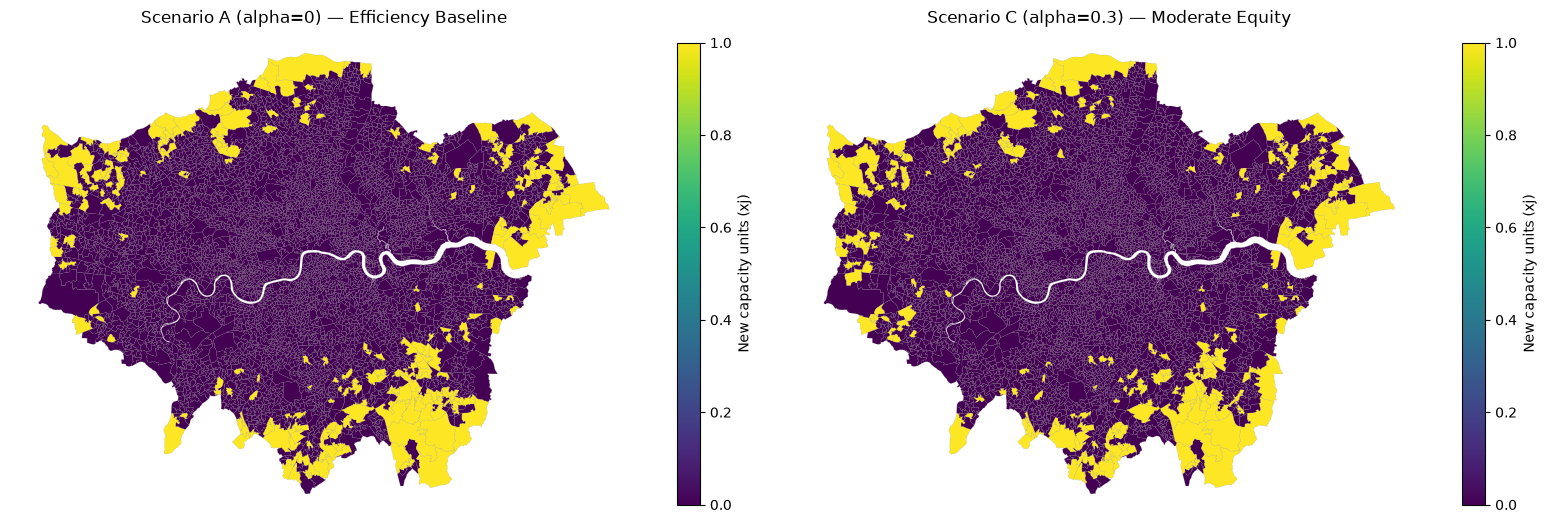

In [9]:
map_data = lsoa_london.merge(results_wide[["lsoa_code", "xj_A_p250", "xj_C_p250"]], on="lsoa_code", how="left")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
map_data.plot(column="xj_A_p250", cmap="viridis", linewidth=0.1, edgecolor="grey",
              legend=True, ax=axes[0], legend_kwds={"label": "New capacity units (xj)", "shrink": 0.6})
axes[0].set_title("Scenario A (alpha=0) — Efficiency Baseline"); axes[0].axis("off")

map_data.plot(column="xj_C_p250", cmap="viridis", linewidth=0.1, edgecolor="grey",
              legend=True, ax=axes[1], legend_kwds={"label": "New capacity units (xj)", "shrink": 0.6})
axes[1].set_title("Scenario C (alpha=0.3) — Moderate Equity"); axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(BASE, "06_outputs/figures/fig_allocation_A_vs_C.png"), dpi=300, bbox_inches="tight")
plt.show()

## 9. Update pipeline_summary.csv

In [10]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
item = "P-median allocation (12 core configs)"
value = f"Done — {len(core_results)} configs, K0={K0:.4f}"
if (pipeline_summary["Item"] == item).any():
    pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
else:
    pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)
pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                                   Item                                                   Count
                          LSOAs loaded (Greater London)                                                    4994
      Household total (Hi sum, validated vs gor:London)                                                 3423845
Total EVSE locations (OpenStreetEV_GLA, all categories)                                                   23015
            On-street EVSE locations (OpenStreetEV_GLA)                                                   21366
          Session records (join_august2025, post-clean)                                                   63105
          Unique EVSEs with >=1 session (ur_j computed)                                                   10465
              eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level) Done (on-street only) — 3157 LSOAs with has_evse_i=True
                 EVSEs matched to LSOA via spatial join                                                 

## 10. Answering the Research Question — H1-H4 and O3/O4

Directly tests the four hypotheses (proposal Section 6) and summarises what O3 (how
allocation shifts with alpha) and O4 (efficiency-equity trade-off, where it plateaus)
actually show, using the full M1-M4 table from the core grid above.

In [11]:
pivot = core_summary.pivot(index="p", columns="scenario", values=["M1_avg_dist_m","M2_coverage_800m","M3_imd_gap","M4_gini"])
print("=== Full M1-M4 table, all 12 configurations ===")
print(pivot.to_string())
print()

r_A, _ = pearsonr(results_wide["xj_A_p250"], diag_table["income_score"])
r_C, _ = pearsonr(results_wide["xj_C_p250"], diag_table["income_score"])
print(f"H1/H2 check (p=250): xj vs income_score correlation -- Scenario A: r={r_A:.4f}, Scenario C: r={r_C:.4f}")
print("  (less negative / more positive in C than A supports H2: equity shift toward deprived LSOAs)")
print()

print("=== H2: M3 (IMD gap) and M4 (Gini), A vs C ===")
for p in P_VALUES:
    row_A = core_summary[(core_summary["scenario"]=="A") & (core_summary["p"]==p)].iloc[0]
    row_C = core_summary[(core_summary["scenario"]=="C") & (core_summary["p"]==p)].iloc[0]
    m3_a, m3_c = row_A["M3_imd_gap"], row_C["M3_imd_gap"]
    m4_a, m4_c = row_A["M4_gini"], row_C["M4_gini"]
    print(f"p={p}: M3 A={m3_a:.4f} -> C={m3_c:.4f}  |  M4 A={m4_a:.4f} -> C={m4_c:.4f}")
print("  (M3 rising toward 0/positive and M4 falling from A to C would support H2)")
print()

print("=== H3: modest efficiency cost -- M1 A vs C ===")
for p in P_VALUES:
    row_A = core_summary[(core_summary["scenario"]=="A") & (core_summary["p"]==p)].iloc[0]
    row_C = core_summary[(core_summary["scenario"]=="C") & (core_summary["p"]==p)].iloc[0]
    m1_a, m1_c = row_A["M1_avg_dist_m"], row_C["M1_avg_dist_m"]
    delta = m1_c - m1_a
    pct = delta / m1_a * 100
    print(f"p={p}: M1 A={m1_a:.1f}m -> C={m1_c:.1f}m ({delta:+.1f}m, {pct:+.1f}%)")
print()

print("=== H4: diminishing returns -- marginal M3 gain A->C vs C->D ===")
for p in P_VALUES:
    m3 = {}
    for s in ["A", "C", "D"]:
        row = core_summary[(core_summary["scenario"]==s) & (core_summary["p"]==p)].iloc[0]
        m3[s] = row["M3_imd_gap"]
    gain_AC = m3["C"] - m3["A"]
    gain_CD = m3["D"] - m3["C"]
    verdict = "diminishing" if abs(gain_CD) < abs(gain_AC) else "NOT diminishing"
    print(f"p={p}: M3 gain A->C = {gain_AC:.4f}, gain C->D = {gain_CD:.4f}  -> {verdict}")

=== Full M1-M4 table, all 12 configurations ===
         M1_avg_dist_m                                     M2_coverage_800m                               M3_imd_gap                                 M4_gini                              
scenario             A           B           C           D                A         B         C         D          A         B         C         D         A         B         C         D
p                                                                                                                                                                                         
100         294.778368  297.727346  296.486781  296.997857         0.870326  0.865814  0.866145  0.864654    0.04051  0.076553  0.102829  0.115960  0.351455  0.351657  0.351855  0.352652
250         227.969542  222.210946  225.248631  225.171264         0.920163  0.924572  0.922721  0.923381   -0.06702 -0.056004 -0.022273  0.024151  0.324460  0.324651  0.324855  0.325052
500         158.0